# Урок 3. kNN

В уроке мы разобрали построение модели kNN на базовом наборе данных Iris. Для лучшего понимания, как работает алгоритм, мы использовали только два признака - длину и ширину лепестка.

Однако другие признаки тоже могли быть важны для получения моделью более детальной информации об объектах и, соответственно, построения более точных прогнозов.

### 1.
Поочередно добавьте к признакам (petal length, petal width) из урока  оставшиеся признаки, чтобы получилось: 1) (sepal length, petal length, petal width); 2) (sepal width, petal length, petal width).

*Примечание: признаки могут быть расположены в любом порядке.*

In [1]:
from sklearn.datasets import load_iris

Напомним порядок расположения признаков в массиве данных

In [2]:
iris_dataset = load_iris()
iris_dataset['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Для формирования массива новых признаков проще воспользоваться не срезами, как мы делали в уроке - iris_dataset.data[:, 2:4] (здесь мы показываем, что выбираем только со 2го по 4й столбец, причем не включая 2й), а просто удалить один из ненужных нам столбцов с помощью функции библиотеки *numpy.delete*

**Пример**

In [3]:
import numpy as np

In [4]:
a = np.array([[ 0,  1,  2,  3],
               [ 4,  5,  6,  7],
               [ 8,  9, 10, 11],
               [12, 13, 14, 15]])

a_new = np.delete(a, 0, axis=1)
a_new

array([[ 1,  2,  3],
       [ 5,  6,  7],
       [ 9, 10, 11],
       [13, 14, 15]])

In [34]:
iris_dataset_1 = np.delete(iris_dataset['data'], 1, axis=1)
columns_1 = np.delete(iris_dataset['feature_names'], 1)
iris_dataset_2 = np.delete(iris_dataset['data'], 0, axis=1)
columns_2 = np.delete(iris_dataset['feature_names'], 0)
# iris_dataset_1[:, 2]
# iris_dataset['target']
iris_dataset_2

array([[3.5, 1.4, 0.2],
       [3. , 1.4, 0.2],
       [3.2, 1.3, 0.2],
       [3.1, 1.5, 0.2],
       [3.6, 1.4, 0.2],
       [3.9, 1.7, 0.4],
       [3.4, 1.4, 0.3],
       [3.4, 1.5, 0.2],
       [2.9, 1.4, 0.2],
       [3.1, 1.5, 0.1],
       [3.7, 1.5, 0.2],
       [3.4, 1.6, 0.2],
       [3. , 1.4, 0.1],
       [3. , 1.1, 0.1],
       [4. , 1.2, 0.2],
       [4.4, 1.5, 0.4],
       [3.9, 1.3, 0.4],
       [3.5, 1.4, 0.3],
       [3.8, 1.7, 0.3],
       [3.8, 1.5, 0.3],
       [3.4, 1.7, 0.2],
       [3.7, 1.5, 0.4],
       [3.6, 1. , 0.2],
       [3.3, 1.7, 0.5],
       [3.4, 1.9, 0.2],
       [3. , 1.6, 0.2],
       [3.4, 1.6, 0.4],
       [3.5, 1.5, 0.2],
       [3.4, 1.4, 0.2],
       [3.2, 1.6, 0.2],
       [3.1, 1.6, 0.2],
       [3.4, 1.5, 0.4],
       [4.1, 1.5, 0.1],
       [4.2, 1.4, 0.2],
       [3.1, 1.5, 0.2],
       [3.2, 1.2, 0.2],
       [3.5, 1.3, 0.2],
       [3.6, 1.4, 0.1],
       [3. , 1.3, 0.2],
       [3.4, 1.5, 0.2],
       [3.5, 1.3, 0.3],
       [2.3, 1.3

### 2.
Теперь посмотрите на трехмерном графике, насколько хорошо данные разделяются по каждой из совокупностей трех параметров.

In [8]:
# если работаете в интерактивной оболочке IPython
%matplotlib inline

from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

**Пример** построения трехмерного графика

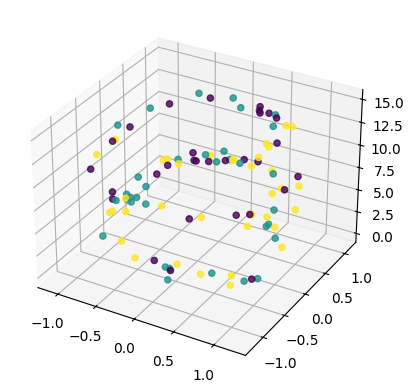

In [23]:
ax = plt.axes(projection='3d')

zdata = 15 * np.random.random(100) # точки оси Z
xdata = np.sin(zdata) + 0.1 * np.random.randn(100) # точки оси X
ydata = np.cos(zdata) + 0.1 * np.random.randn(100) # точки оси Y
colors = np.random.randint(3, size=100)

ax.scatter3D(xdata, ydata, zdata, alpha=.8, c=colors)

**Примечание: для установки цвета в функции используйте *c=iris_dataset.target*.**

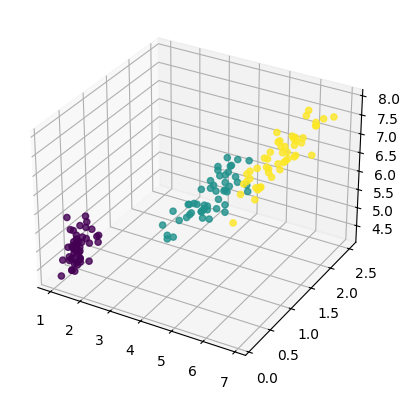

In [24]:
ax = plt.axes(projection='3d')

zdata = iris_dataset_1[:,0] # точки оси Z
xdata = iris_dataset_1[:, 1] # точки оси X
ydata = iris_dataset_1[:, 2] # точки оси Y
colors = iris_dataset['target']
ax.scatter3D(xdata, ydata, zdata, alpha=.8, c=colors)

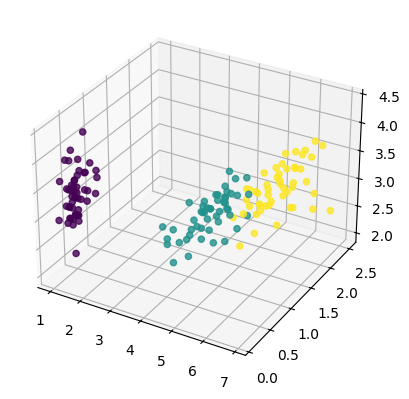

In [26]:
ax = plt.axes(projection='3d')

zdata = iris_dataset_2[:,0] # точки оси Z
xdata = iris_dataset_2[:, 1] # точки оси X
ydata = iris_dataset_2[:, 2] # точки оси Y
colors = iris_dataset['target']
ax.scatter3D(xdata, ydata, zdata, alpha=.8, c=colors)

### 3.
С помощью функции sklearn.model_selection.train_test_split разделите данные на тренировочный и тестовый датасеты и затем, применив библиотечную версию алгоритма sklearn.neighbors.KNeighborsClassifier, постройте модель для наборов данных *iris_dataset_1* и *iris_dataset_2* (по умолчанию используйте n_neighbors=5).

*Примечание: в функции train_test_split используйте параметр random_state=17 для воспроизводимости результатов.*

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [35]:
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(iris_dataset_1,
                                                    iris_dataset['target'],
                                                    random_state=17) # random_state - для воспроизводимости



x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(iris_dataset_2,
                                                    iris_dataset['target'],
                                                    random_state=17) # random_state - для воспроизводимости

knn = KNeighborsClassifier(n_neighbors=5)

knn1_model = knn.fit(x_train_1, y_train_1)
knn2_model = knn.fit(x_train_2, y_train_2)
knn1_predict = knn.predict(x_test_1)
knn2_predict = knn.predict(x_test_2)
print(knn1_predict)
print(knn2_predict)


[0 1 2 1 2 2 1 2 1 2 2 0 1 0 2 0 0 2 2 2 2 0 2 1 1 1 1 1 0 1 0 0 0 0 1 1 1
 2]
[0 1 2 1 2 2 1 2 1 2 2 0 1 0 2 0 0 2 2 2 1 0 2 1 1 1 1 1 0 1 0 1 0 0 1 1 1
 2]


### 4.
Проверьте точность работы обеих моделей, используя встроенную функцию sklearn.metrics.accuracy_score. Сравните результат их работы с результатом, полученным на наборе данных с двумя признаками (который разбирался в уроке), и укажите ответ.

In [29]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_1 = accuracy_score(y_test_1, knn1_predict)
accuracy_2 = accuracy_score(y_test_2, knn2_predict)

print(f'Accuracy_1: {accuracy_1}, accuracy_2: {accuracy_2}')

Accuracy_1: 0.9736842105263158, accuracy_2: 0.9736842105263158


### 5.
Постройте модель на данных *x_train_1, y_train_1* с гиперпараметром n_neighbors, пробегающим значения от 1 до 20 включительно, и укажите значения n_neighbors, которым соответствует наиболее высокий результат функции accuracy_score().

*Примечание: можно воспользоваться циклом for, чтобы не прописывать вручную все 20 вариаций модели.*

In [37]:
acc_max = 0
n_neighbors_best = 1
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn_model = knn.fit(x_train_1, y_train_1)
    knn_predict = knn.predict(x_test_1)
    accuracy = accuracy_score(y_test_1, knn_predict)
    print(f'Accuracy_{i}: {accuracy}')
    if accuracy > acc_max:
        acc_max = accuracy
        n_neighbors_best = i
        
print(f'Accuracy best: {acc_max}, neightbors best: {n_neighbors_best}')

Accuracy_1: 0.9736842105263158
Accuracy_2: 0.9736842105263158
Accuracy_3: 0.9736842105263158
Accuracy_4: 0.9473684210526315
Accuracy_5: 0.9736842105263158
Accuracy_6: 0.9473684210526315
Accuracy_7: 0.9473684210526315
Accuracy_8: 0.9210526315789473
Accuracy_9: 0.9473684210526315
Accuracy_10: 0.9473684210526315
Accuracy_11: 0.9736842105263158
Accuracy_12: 0.9210526315789473
Accuracy_13: 0.9473684210526315
Accuracy_14: 0.9210526315789473
Accuracy_15: 0.9736842105263158
Accuracy_16: 0.9473684210526315
Accuracy_17: 0.9473684210526315
Accuracy_18: 0.9210526315789473
Accuracy_19: 0.9210526315789473
Accuracy_20: 0.9210526315789473
Accuracy best: 0.9736842105263158, neightbors best: 1
